In [8]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Define paths and experiment parameters
REPO_ROOT = "/home/felix_jaspersen/Repositories/HEBO/MCBO"
results_dir = "results/Ackley Function 50-nom-2 3-num/GP (mat52 and TO) - Tr-based IS acq optim"
results_dir = os.path.join(REPO_ROOT, results_dir)

# Experimental seetings used
n_init = 20  # Number of initial random samples you used

# Find all the seed CSV files
csv_files = glob.glob(os.path.join(results_dir, "seed_*_results.csv"))
csv_files.sort()

if not csv_files:
    print(f"No CSV files found in: {results_dir}")

In [3]:
# 1. Force Jupyter to render plots (Overrides the MCBO 'Agg' setting)
%matplotlib inline

import os
import numpy as np
import matplotlib.pyplot as plt

# Import MCBO's native tools
from mcbo.utils.experiment_utils import get_opt_results
from mcbo.utils.general_plot_utils import plot_curves_with_ranked_legends

# Define your paths and parameters
REPO_ROOT = "/home/felix_jaspersen/Repositories/HEBO/MCBO" 
RESULTS_DIR = os.path.join(REPO_ROOT, "results")


# Ackley53D

In [7]:
# Experiment details
n_init = 20
method_name = "Casmopolitan (gp_to)"

# Let MCBO automatically find and load all seeds
results_df = get_opt_results(
    task_id="ackley-53", 
    opt_short_name="gp_to__is__ei__basic", 
    seeds=[42, 43, 44],
    result_dir=RESULTS_DIR
)

results_df.head()

,Task,Optimizer,Model,Acq opt,Acq func,TR,Seed,Eval Num,f(x),f(x*),Elapsed Time
0,Ackley Function 50-nom-2 3-num,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,1,2.744155,"tensor(2.7442, dtype=torch.float64)",0.044602
1,Ackley Function 50-nom-2 3-num,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,2,2.662415,"tensor(2.6624, dtype=torch.float64)",0.084215
2,Ackley Function 50-nom-2 3-num,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,3,2.906920,"tensor(2.6624, dtype=torch.float64)",0.123895
3,Ackley Function 50-nom-2 3-num,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,4,2.841668,"tensor(2.6624, dtype=torch.float64)",0.162809
4,Ackley Function 50-nom-2 3-num,GP (mat52 and TO) - Tr-based IS acq optim,GP (mat52 and TO),IS,EI,basic,42,5,2.749591,"tensor(2.6624, dtype=torch.float64)",0.201502


In [ ]:
%matplotlib inline
# Quick cleaner for PyTorch tensor strings
# if results_df['f(x*)'].dtype == object:
#     results_df['f(x*)'] = results_df['f(x*)'].astype(str).str.extract(r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)')[0].astype(float)

# Groups dataframe by Seed. Iterate over each group. Grab the optimal value column. Result are #seeds numpy arrays in a list.
grouped_fx = [group["f(x*)"].values for seed, group in results_df.groupby("Seed")]
# Finds the shortest array of all the seeds.
min_len = min(len(arr) for arr in grouped_fx)


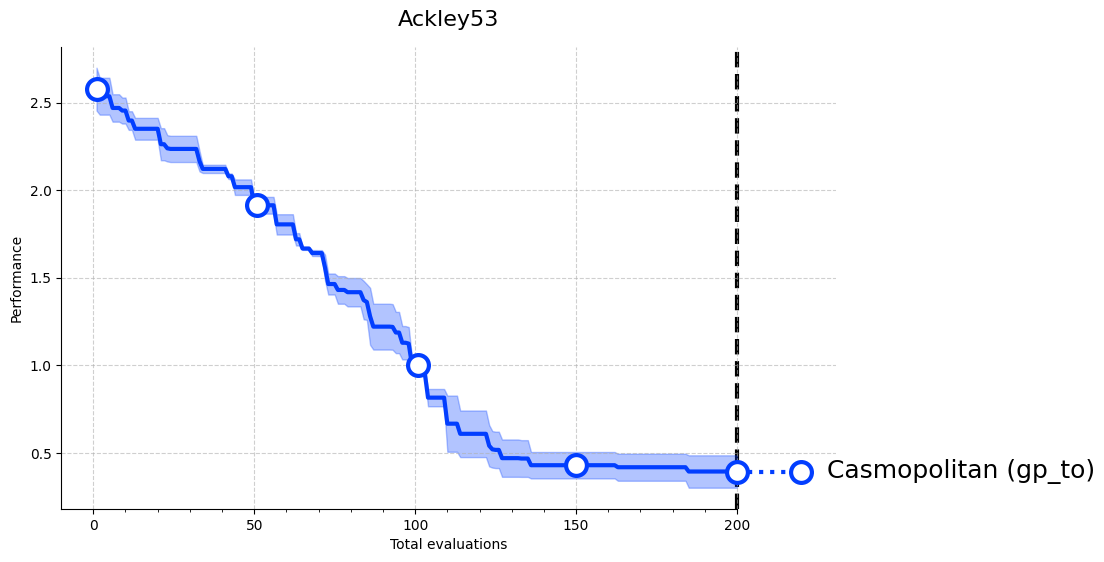

In [14]:
# Dictionaries for Plot 1 (Total Evaluations)
# Reformat into the dictionary structure the plotter expects
data_y_total = {method_name: np.stack([arr[:min_len] for arr in grouped_fx])}
data_x_total = {method_name: np.arange(1, min_len + 1)}

fig, ax = plt.subplots(figsize=(10, 6))
plot_curves_with_ranked_legends(
    ax=ax,
    data_y=data_y_total,
    data_x=data_x_total,
    show_std_error=True,
    min_is_the_best=True
)
plt.title("Ackley53", fontsize=16, pad=15)
plt.xlabel("Total evaluations")
plt.ylabel("Performance")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

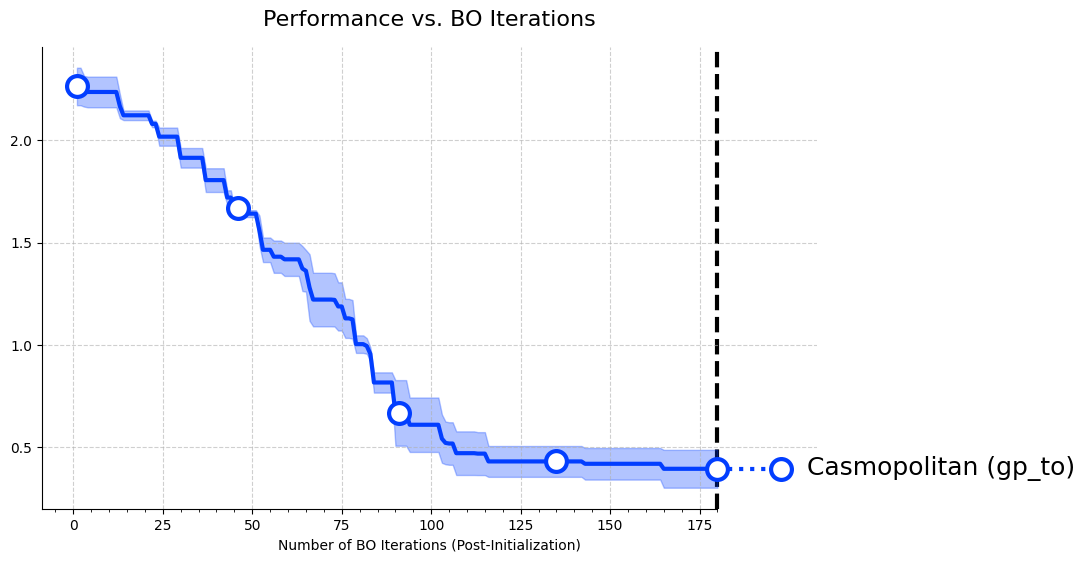

In [13]:
# Dictionaries for Plot 2 (BO Iterations Only)
data_y_bo = {method_name: data_y_total[method_name][:, n_init:]}
data_x_bo = {method_name: data_x_total[method_name][n_init:] - n_init}

fig, ax = plt.subplots(figsize=(10, 6))
plot_curves_with_ranked_legends(
    ax=ax,
    data_y=data_y_bo,
    data_x=data_x_bo,
    show_std_error=True,
    min_is_the_best=True
)
plt.title("Performance vs. BO Iterations", fontsize=16, pad=15)
plt.xlabel("Number of BO Iterations (Post-Initialization)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# CoCaBo
